# VAE — LPC 스프라이트 생성 (TensorFlow)

64×64 RGBA 스프라이트 프레임으로 학습하는 합성곱 변분 오토인코더.  
백엔드: TensorFlow 2.x + Keras (Metal GPU 자동 감지)

## 1. 환경 설정

In [116]:
import os
import random
import time
from pathlib import Path
from collections import Counter

# 노트북 실행 위치와 관계없이 항상 프로젝트 루트를 CWD로 고정
_PROJECT_ROOT = Path(__file__).parent if '__file__' in dir() else Path(os.path.abspath(''))
# 현재 디렉토리가 프로젝트 루트가 아니면 한 단계씩 올라가며 dataset 폴더를 찾음
for _p in [_PROJECT_ROOT] + list(_PROJECT_ROOT.parents):
    if (_p / 'dataset' / 'processed').exists():
        os.chdir(_p)
        break
print(f'CWD: {Path.cwd()}')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # 불필요한 TF 로그 억제
import tensorflow as tf

# Metal GPU 확인
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)  # 필요한 만큼만 메모리 할당

DEVICE = '/GPU:0' if gpus else '/CPU:0'
print(f'TensorFlow : {tf.__version__}')
print(f'사용 디바이스 : {DEVICE}')
print(f'논리 디바이스 : {[d.name for d in tf.config.list_logical_devices()]}')

CWD: /Users/gomuseo/Desktop/Python/vae_test
TensorFlow : 2.16.2
사용 디바이스 : /GPU:0
논리 디바이스 : ['/device:CPU:0', '/device:GPU:0']


## 2. 설정값

In [117]:
CFG = dict(
    # 데이터
    processed_root = Path('dataset/processed'),
    categories     = ['body'],     # None이면 전체 카테고리 사용
    img_size       = 64,
    channels       = 4,          # RGBA 4채널
    val_ratio      = 0.02,

    # 모델
    latent_dim     = 128,
    base_channels  = 32,         # 첫 번째 Conv 출력 채널 수 (레이어마다 2배)

    # 학습
    epochs         = 50,
    batch_size     = 128,
    lr             = 0.01,
    beta           = 1.0,        # KL 가중치 (beta-VAE: 2~4로 올리면 더 좋은 분리)
    prefetch       = tf.data.AUTOTUNE,
    parallel_calls = tf.data.AUTOTUNE,

    # 기타
    seed           = 42,
    save_dir       = Path('checkpoints_tf'),
)

CFG['save_dir'].mkdir(exist_ok=True)
tf.random.set_seed(CFG['seed'])
np.random.seed(CFG['seed'])
random.seed(CFG['seed'])
print('설정 완료.')

설정 완료.


## 3. 데이터셋

In [118]:
def collect_paths(root: Path, categories=None) -> list:
    """전처리된 PNG 파일 경로 목록을 수집합니다."""
    if categories is None:
        return sorted(str(p) for p in root.rglob('*.png'))
    paths = []
    for cat in categories:
        paths += sorted(str(p) for p in (root / cat).glob('*.png'))
    return paths


def decode_image(path: tf.Tensor) -> tf.Tensor:
    """파일 경로 → float32 RGBA 텐서 (H, W, 4) [0, 1]"""
    raw  = tf.io.read_file(path)
    img  = tf.image.decode_png(raw, channels=4)   # uint8 (64,64,4)
    return tf.cast(img, tf.float32) / 255.0


def build_dataset(paths: list, batch_size: int, shuffle: bool) -> tf.data.Dataset:
    """경로 목록 → 학습용 tf.data.Dataset"""
    if len(paths) == 0:
        raise ValueError(f'경로 목록이 비어 있습니다. CWD={Path.cwd()} — dataset/processed 경로를 확인하세요.')
    ds = tf.data.Dataset.from_tensor_slices(paths)
    if shuffle:
        ds = ds.shuffle(buffer_size=min(50_000, len(paths)), seed=CFG['seed'])
    ds = ds.map(decode_image, num_parallel_calls=CFG['parallel_calls'])
    ds = ds.batch(batch_size, drop_remainder=True)
    ds = ds.prefetch(CFG['prefetch'])
    return ds


# 경로 수집 및 분할
all_paths = collect_paths(CFG['processed_root'], CFG['categories'])
random.shuffle(all_paths)

n_val    = int(len(all_paths) * CFG['val_ratio'])
n_train  = len(all_paths) - n_val
train_paths = all_paths[:n_train]
val_paths   = all_paths[n_train:]

train_ds = build_dataset(train_paths, CFG['batch_size'], shuffle=True)
val_ds   = build_dataset(val_paths,   CFG['batch_size'], shuffle=False)

print(f'전체 프레임 : {len(all_paths):,}')
print(f'학습        : {n_train:,}')
print(f'검증        : {n_val:,}')
print(f'배치/에폭   : {n_train // CFG["batch_size"]:,}')

# 배치 shape 확인
sample_batch = next(iter(train_ds))
print(f'배치 shape  : {sample_batch.shape}  dtype={sample_batch.dtype}')

전체 프레임 : 4,544
학습        : 4,454
검증        : 90
배치/에폭   : 34
배치 shape  : (128, 64, 64, 4)  dtype=<dtype: 'float32'>


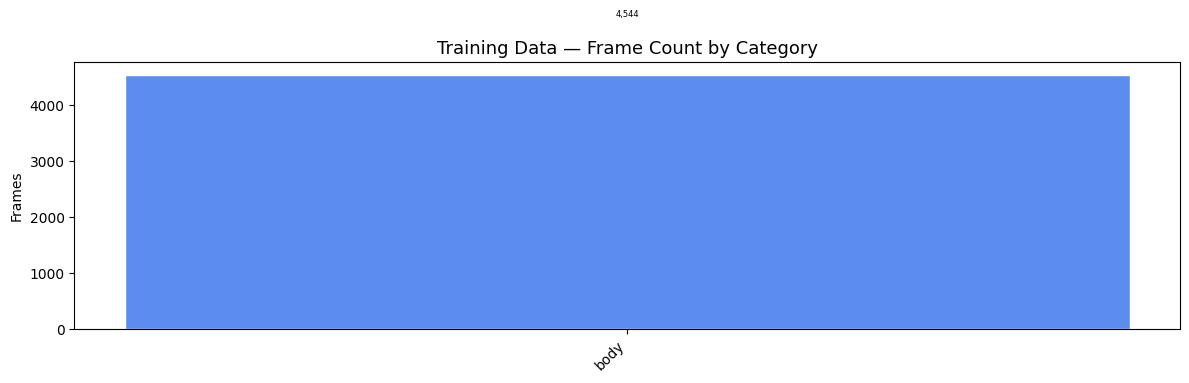

In [119]:
# 전체 데이터셋 카테고리 분포
cat_counts = Counter()
for p in all_paths:
    cat_counts[Path(p).relative_to(CFG['processed_root']).parts[0]] += 1

cats, cnts = zip(*cat_counts.most_common())
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(cats, cnts, color='#5b8dee', edgecolor='white')
ax.set_title('Training Data — Frame Count by Category', fontsize=13)
ax.set_ylabel('Frames')
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats, rotation=45, ha='right')
for bar, v in zip(bars, cnts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{v:,}', ha='center', va='bottom', fontsize=6)
plt.tight_layout()
plt.show()

/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_68281/1766767583.py:20: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_68281/1766767583.py:20: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_68281/1766767583.py:20: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_68281/1766767583.py:20: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_68281/1766767583.py:20: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipyke

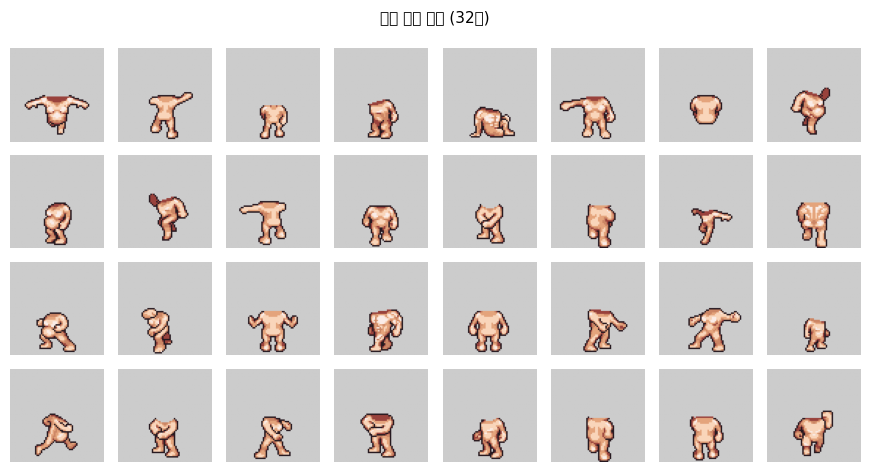

In [120]:
def show_batch(tensor, title='', n=32, bg=(0.8, 0.8, 0.8)):
    """(B, H, W, 4) 텐서에서 최대 n개의 RGBA 프레임을 시각화합니다."""
    n   = min(n, tensor.shape[0])
    nc  = 8
    nr  = (n + nc - 1) // nc
    fig, axes = plt.subplots(nr, nc, figsize=(nc * 1.1, nr * 1.2))
    axes = np.array(axes).flatten()
    imgs = tensor[:n].numpy()   # (N, H, W, 4)
    for ax, img in zip(axes, imgs):
        # 배경색 위에 RGBA 합성
        alpha = img[:, :, 3:4]
        rgb   = img[:, :, :3]
        comp  = rgb * alpha + np.array(bg) * (1 - alpha)
        ax.imshow(np.clip(comp, 0, 1))
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    if title:
        plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

show_batch(sample_batch, title='학습 배치 샘플 (32장)')

## 4. 모델 아키텍처

In [121]:
def build_encoder(img_size=64, channels=4, base_ch=32, latent_dim=256):
    """
    4 × Conv2D(stride=2) → Flatten → Dense(μ) + Dense(log σ²)
    공간 크기: 64 → 32 → 16 → 8 → 4  (4단계 다운샘플)
    입력 포맷: (B, H, W, C)  — TensorFlow NHWC
    """
    inp = tf.keras.Input(shape=(img_size, img_size, channels), name='encoder_input')
    x   = inp
    ch  = base_ch
    for i in range(4):
        x  = tf.keras.layers.Conv2D(ch, 4, strides=2, padding='same', name=f'enc_conv{i}')(x)
        x  = tf.keras.layers.BatchNormalization(momentum=0.9, name=f'enc_bn{i}')(x)
        x  = tf.keras.layers.LeakyReLU(0.2, name=f'enc_act{i}')(x)
        ch *= 2
    x   = tf.keras.layers.Flatten(name='enc_flat')(x)
    mu      = tf.keras.layers.Dense(latent_dim, name='mu')(x)
    log_var = tf.keras.layers.Dense(latent_dim, name='log_var')(x)
    return tf.keras.Model(inp, [mu, log_var], name='encoder')


def build_decoder(img_size=64, channels=4, base_ch=32, latent_dim=256):
    """
    Dense → Reshape → 4 × Conv2DTranspose(stride=2) → Sigmoid
    공간 크기: 4 → 8 → 16 → 32 → 64
    """
    start_ch  = base_ch * 8    # 인코더 마지막 채널과 대칭
    start_sp  = img_size // 16  # 4×4

    inp = tf.keras.Input(shape=(latent_dim,), name='decoder_input')
    x   = tf.keras.layers.Dense(start_sp * start_sp * start_ch, name='dec_fc')(inp)
    x   = tf.keras.layers.Reshape((start_sp, start_sp, start_ch), name='dec_reshape')(x)

    out_chs = [base_ch * 4, base_ch * 2, base_ch, channels]
    for i, out_ch in enumerate(out_chs):
        x = tf.keras.layers.Conv2DTranspose(
            out_ch, 4, strides=2, padding='same', name=f'dec_conv{i}'
        )(x)
        if i < len(out_chs) - 1:
            x = tf.keras.layers.BatchNormalization(momentum=0.9, name=f'dec_bn{i}')(x)
            x = tf.keras.layers.ReLU(name=f'dec_act{i}')(x)
        else:
            x = tf.keras.layers.Activation('sigmoid', name='dec_out')(x)  # 최종 출력 → [0,1]

    return tf.keras.Model(inp, x, name='decoder')


print('인코더 / 디코더 빌더 정의 완료.')

인코더 / 디코더 빌더 정의 완료.


In [122]:
class VAE(tf.keras.Model):
    """인코더 + 재매개변수화 + 디코더로 구성된 VAE 모델."""

    def __init__(self, img_size, channels, base_ch, latent_dim, beta=1.0):
        super().__init__()
        self.latent_dim = latent_dim
        self.beta       = beta
        self.encoder    = build_encoder(img_size, channels, base_ch, latent_dim)
        self.decoder    = build_decoder(img_size, channels, base_ch, latent_dim)

        # 손실값 추적용 Metric
        self.total_loss_tracker = tf.keras.metrics.Mean(name='loss')
        self.recon_loss_tracker = tf.keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker    = tf.keras.metrics.Mean(name='kl_loss')

    def reparameterize(self, mu, log_var):
        """재매개변수화 기법: z = μ + ε·σ  (ε ~ N(0,I))"""
        eps = tf.random.normal(tf.shape(mu))
        return mu + eps * tf.exp(0.5 * log_var)

    def call(self, x, training=False):
        """순전파: 입력 → (복원, μ, log_var)"""
        mu, log_var = self.encoder(x, training=training)
        z           = self.reparameterize(mu, log_var)
        recon       = self.decoder(z, training=training)
        return recon, mu, log_var

    def compute_loss(self, x):
        """손실 계산: MSE 복원 손실 + β·KL 발산 (배치 평균으로 정규화)"""
        recon, mu, log_var = self(x, training=True)
        batch      = tf.cast(tf.shape(x)[0], tf.float32)
        recon_loss = tf.reduce_sum(tf.square(x - recon)) / batch
        kl_loss    = -0.5 * tf.reduce_sum(
            1 + log_var - tf.square(mu) - tf.exp(log_var)
        ) / batch
        total = recon_loss + self.beta * kl_loss
        return total, recon_loss, kl_loss

    def train_step(self, x):
        """학습 스텝: GradientTape로 역전파 수행"""
        with tf.GradientTape() as tape:
            total, recon_loss, kl_loss = self.compute_loss(x)
        grads = tape.gradient(total, self.trainable_variables)
        # 그래디언트 클리핑
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(total)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            'loss'      : self.total_loss_tracker.result(),
            'recon_loss': self.recon_loss_tracker.result(),
            'kl_loss'   : self.kl_loss_tracker.result(),
        }

    def test_step(self, x):
        """검증 스텝"""
        total, recon_loss, kl_loss = self.compute_loss(x)
        self.total_loss_tracker.update_state(total)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            'loss'      : self.total_loss_tracker.result(),
            'recon_loss': self.recon_loss_tracker.result(),
            'kl_loss'   : self.kl_loss_tracker.result(),
        }

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def sample(self, n):
        """사전 분포 N(0,I)에서 n개 이미지 생성"""
        z = tf.random.normal((n, self.latent_dim))
        return self.decoder(z, training=False)


with tf.device(DEVICE):
    model = VAE(
        img_size   = CFG['img_size'],
        channels   = CFG['channels'],
        base_ch    = CFG['base_channels'],
        latent_dim = CFG['latent_dim'],
        beta       = CFG['beta'],
    )

# 파라미터 수 확인을 위해 더미 입력으로 빌드
dummy = tf.zeros((1, CFG['img_size'], CFG['img_size'], CFG['channels']))
_ = model(dummy)

enc_params = model.encoder.count_params()
dec_params = model.decoder.count_params()
print(f'인코더 파라미터 : {enc_params:,}')
print(f'디코더 파라미터 : {dec_params:,}')
print(f'전체 파라미터   : {enc_params + dec_params:,}')

인코더 파라미터 : 1,741,408
디코더 파라미터 : 1,219,684
전체 파라미터   : 2,961,092


In [123]:
# 순전파 shape 확인
dummy = tf.zeros((4, CFG['img_size'], CFG['img_size'], CFG['channels']))
recon, mu, log_var = model(dummy)
print(f'입력      : {dummy.shape}')
print(f'복원 출력 : {recon.shape}  범위=[{recon.numpy().min():.3f}, {recon.numpy().max():.3f}]')
print(f'μ         : {mu.shape}')
print(f'log_var   : {log_var.shape}')

입력      : (4, 64, 64, 4)
복원 출력 : (4, 64, 64, 4)  범위=[0.490, 0.511]
μ         : (4, 128)
log_var   : (4, 128)


In [124]:
# 인코더 / 디코더 구조 요약
model.encoder.summary()
print()
model.decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 64, 64, 4) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_conv0 (Conv2D)  │ (None, 32, 32,    │      2,080 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bn0             │ (None, 32, 32,    │        128 │ enc_conv0[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_act0            │ (None, 32, 32,    │          0 │ enc_bn0[0][0]     │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_conv1 (Conv2D)  │ (None, 16, 16,    │     32,832 │ enc_act0[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bn1             │ (None, 16, 16,    │        256 │ enc_conv1[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_act1            │ (None, 16, 16,    │          0 │ enc_bn1[0][0]     │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_conv2 (Conv2D)  │ (None, 8, 8, 128) │    131,200 │ enc_act1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bn2             │ (None, 8, 8, 128) │        512 │ enc_conv2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_act2            │ (None, 8, 8, 128) │          0 │ enc_bn2[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_conv3 (Conv2D)  │ (None, 4, 4, 256) │    524,544 │ enc_act2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bn3             │ (None, 4, 4, 256) │      1,024 │ enc_conv3[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_act3            │ (None, 4, 4, 256) │          0 │ enc_bn3[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_flat (Flatten)  │ (None, 4096)      │          0 │ enc_act3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 128)       │    524,416 │ enc_flat[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 128)       │    524,416 │ enc_flat[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,741,408 (6.64 MB)

 Trainable params: 1,740,448 (6.64 MB)

 Non-trainable params: 960 (3.75 KB)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_fc (Dense)                  │ (None, 4096)           │       528,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_reshape (Reshape)           │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv0 (Conv2DTranspose)     │ (None, 8, 8, 128)      │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn0 (BatchNormalization)    │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act0 (ReLU)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2DTranspose)     │ (None, 16, 16, 64)     │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn1 (BatchNormalization)    │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act1 (ReLU)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2DTranspose)     │ (None, 32, 32, 32)     │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn2 (BatchNormalization)    │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act2 (ReLU)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv2DTranspose)     │ (None, 64, 64, 4)      │         2,052 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_out (Activation)            │ (None, 64, 64, 4)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,219,684 (4.65 MB)

 Trainable params: 1,219,236 (4.65 MB)

 Non-trainable params: 448 (1.75 KB)

## 5. 손실 함수

In [125]:
# 손실 함수 단위 테스트
x_t = tf.random.uniform((8, 64, 64, 4))
total, recon, kl = model.compute_loss(x_t)
print(f'총 손실     : {total.numpy():.6f}')
print(f'복원 손실   : {recon.numpy():.6f}  (MSE, 픽셀 단위 평균)')
print(f'KL 발산     : {kl.numpy():.6f}  (학습 초기에는 작은 값 정상)')

총 손실     : 1665.763672
복원 손실   : 1555.807861  (MSE, 픽셀 단위 평균)
KL 발산     : 109.955826  (학습 초기에는 작은 값 정상)


## 6. 학습

In [126]:
# 옵티마이저 및 스케줄러 설정
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = CFG['lr'],
    decay_steps           = CFG['epochs'] * (n_train // CFG['batch_size']),
    alpha                 = 1e-5 / CFG['lr'],   # 최소 lr = 1e-5
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
model.compile(optimizer=optimizer)
print('컴파일 완료.')

컴파일 완료.


In [127]:
# 콜백 설정
patience = max(1, CFG['epochs'] // 10)   # patience = epoch / 10

callbacks = [
    # 최적 검증 손실 기준 체크포인트 저장
    tf.keras.callbacks.ModelCheckpoint(
        filepath          = str(CFG['save_dir'] / 'best.weights.h5'),
        monitor           = 'val_loss',
        save_best_only    = True,
        save_weights_only = True,
        verbose           = 1,
    ),
    # Early Stopping: patience 에폭 동안 val_loss 개선 없으면 조기 종료
    tf.keras.callbacks.EarlyStopping(
        monitor              = 'val_loss',
        patience             = patience,
        restore_best_weights = True,
        verbose              = 1,
    ),
    # 학습률 로깅 — lr_schedule을 직접 호출해야 함 (optimizer.learning_rate는 EagerTensor)
    tf.keras.callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: logs.update(
            {'lr': float(lr_schedule(optimizer.iterations))}
        )
    ),
]
print(f'Early Stopping patience: {patience} 에폭')

# 학습 시작
t_start = time.time()
history = model.fit(
    train_ds,
    epochs          = CFG['epochs'],
    validation_data = val_ds,
    callbacks       = callbacks,
    verbose         = 1,
)
elapsed = time.time() - t_start
print(f'\n학습 완료 — 소요 시간: {elapsed/60:.1f}분')
print(f'실제 학습 에폭: {len(history.history["loss"])} / {CFG["epochs"]}')

Early Stopping patience: 5 에폭
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 225ms/step - kl_loss: 3122.6816 - loss: 4176.0371 - recon_loss: 1053.3557 - lr: 0.0100
Epoch 2/50


/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):
/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: kl_loss,loss,recon_loss
  current = self.get_monitor_value(logs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 203ms/step - kl_loss: 215.6217 - loss: 683.4068 - recon_loss: 467.7851 - lr: 0.0100
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 199ms/step - kl_loss: 38.1820 - loss: 353.0699 - recon_loss: 314.8879 - lr: 0.0099
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 205ms/step - kl_loss: 23.7451 - loss: 282.3664 - recon_loss: 258.6213 - lr: 0.0098
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 211ms/step - kl_loss: 19.1665 - loss: 252.3550 - recon_loss: 233.1885 - lr: 0.0098
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 203ms/step - kl_loss: 17.6852 - loss: 224.2305 - recon_loss: 206.5454 - lr: 0.0096
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step - kl_loss: 17.3575 - loss: 203.8274 - recon_loss: 186.4699 - lr: 0.0095
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 204ms/step - kl_loss: 15.6562 - loss: 186.1015 - recon_loss: 170.4453 - lr: 0.0094
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step - kl_loss: 14.9432 - loss: 171.8165 - recon_loss: 156.8733 - lr: 0.0092
Epoch 10/50
34/34 

## 7. 학습 곡선

기록된 키: ['kl_loss', 'loss', 'recon_loss', 'lr']


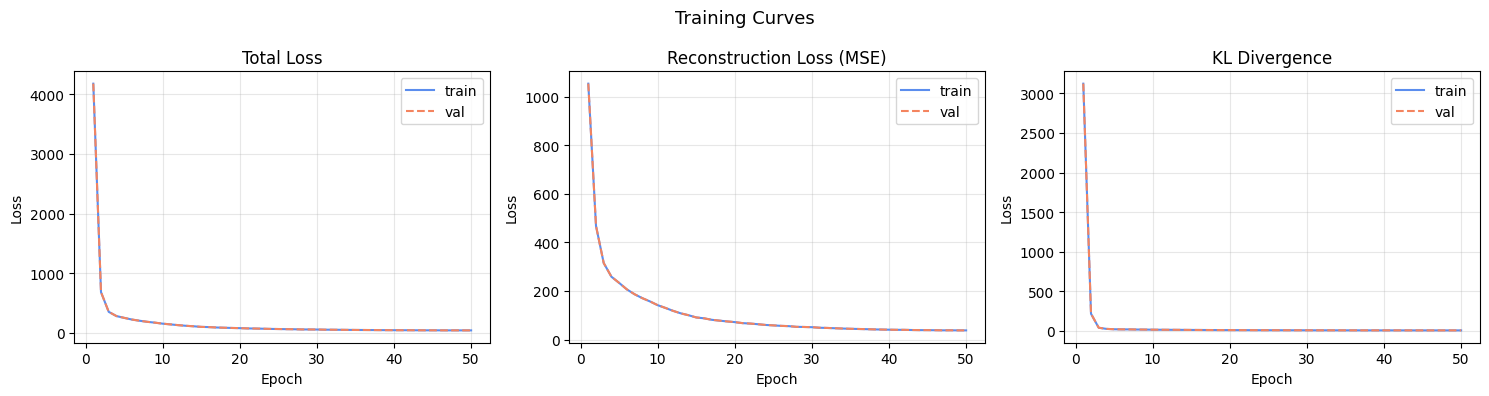

In [128]:
hist     = history.history
print('기록된 키:', list(hist.keys()))

epochs_x = range(1, len(hist['loss']) + 1)
keys     = ['loss', 'recon_loss', 'kl_loss']
titles   = ['Total Loss', 'Reconstruction Loss (MSE)', 'KL Divergence']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key, title in zip(axes, keys, titles):
    ax.plot(epochs_x, hist[key], label='train', color='#5b8dee')
    if key in hist:
        ax.plot(epochs_x, hist[key], label='val', color='#f4845f', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

## 8. 복원 결과

최적 가중치 로드 완료.


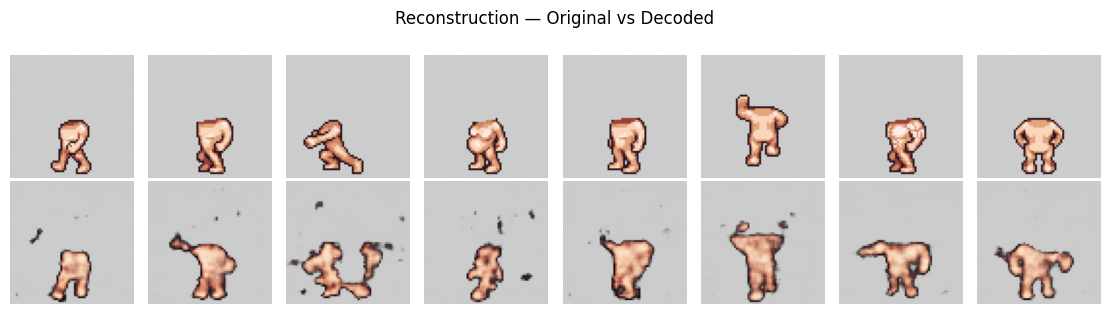

In [129]:
# 최적 가중치 로드
best_ckpt = CFG['save_dir'] / 'best.weights.h5'
if best_ckpt.exists():
    model.load_weights(str(best_ckpt))
    print('최적 가중치 로드 완료.')
else:
    print('체크포인트 없음 — 현재 가중치 사용.')

def to_rgb_list(tensor, bg=(0.8, 0.8, 0.8)):
    """(N, H, W, 4) → 배경 합성 RGB 배열 리스트"""
    imgs = tensor.numpy() if hasattr(tensor, 'numpy') else np.array(tensor)
    out  = []
    for img in imgs:
        comp = img[:, :, :3] * img[:, :, 3:4] + np.array(bg) * (1 - img[:, :, 3:4])
        out.append(np.clip(comp, 0, 1))
    return out

# val_ds 없으면 train_ds 대체
try:
    src_batch = next(iter(val_ds))
except Exception:
    src_batch = next(iter(train_ds))

n_show    = min(8, src_batch.shape[0])
src_batch = src_batch[:n_show]
recon_out, _, _ = model(src_batch, training=False)

origs  = to_rgb_list(src_batch)
recons = to_rgb_list(recon_out)

fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.4, 3.2))
axes = np.array(axes).reshape(2, n_show)

for i in range(n_show):
    axes[0, i].imshow(origs[i]);  axes[0, i].axis('off')
    axes[1, i].imshow(recons[i]); axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original',      fontsize=9)
axes[1, 0].set_ylabel('Reconstructed', fontsize=9)

plt.suptitle('Reconstruction — Original vs Decoded', fontsize=12)
plt.tight_layout()
plt.show()

## 9. 생성 — 사전 분포에서 샘플링

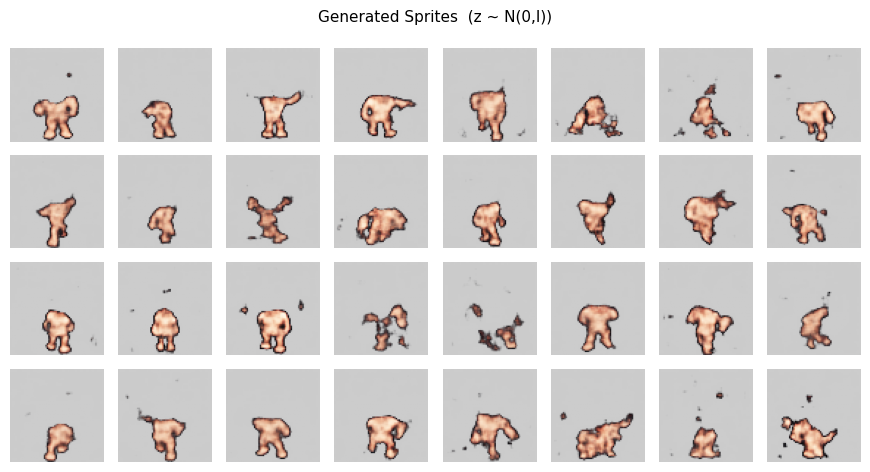

In [130]:
generated = model.sample(32)
show_batch(generated, title='Generated Sprites  (z ~ N(0,I))', n=32)

## 10. 잠재 공간 보간

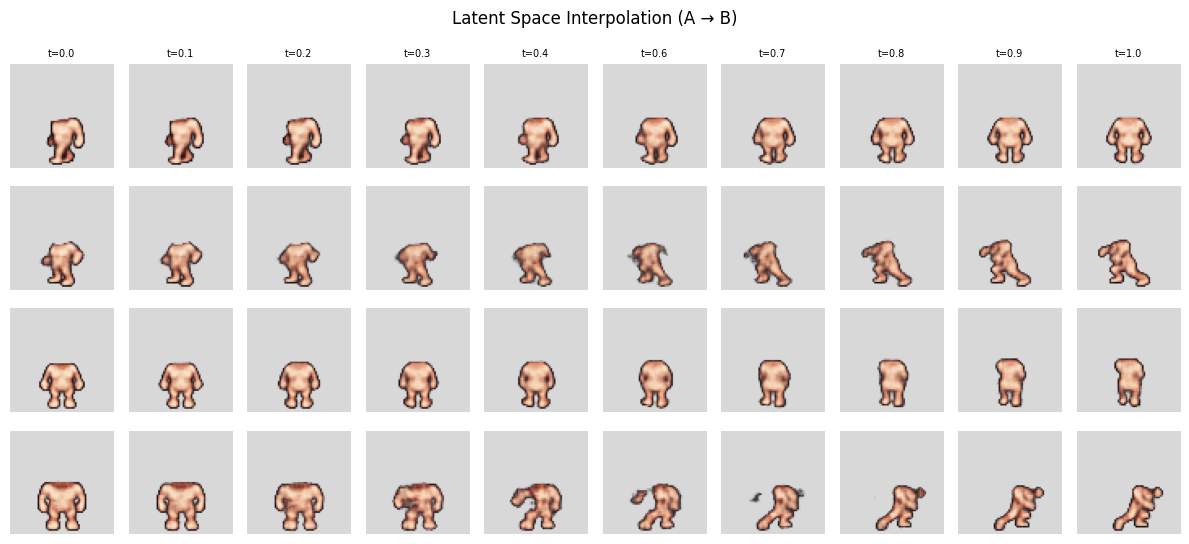

In [131]:
def interpolate(vae, img_a, img_b, steps=10):
    """잠재 공간에서 두 이미지 사이를 선형 보간합니다."""
    mu_a, _ = vae.encoder(tf.expand_dims(img_a, 0), training=False)
    mu_b, _ = vae.encoder(tf.expand_dims(img_b, 0), training=False)
    zs = [(1.0 - t) * mu_a + t * mu_b for t in np.linspace(0, 1, steps)]
    return tf.concat([vae.decoder(z, training=False) for z in zs], axis=0)

n_pairs = 4
steps   = 10

try:
    src_imgs = next(iter(val_ds))
except Exception:
    src_imgs = next(iter(train_ds))

# 실제 이미지 수에 맞게 n_pairs 조정
n_pairs = min(n_pairs, src_imgs.shape[0] // 2)

bg = (0.85, 0.85, 0.85)
fig, axes = plt.subplots(n_pairs, steps, figsize=(steps * 1.2, n_pairs * 1.4))
axes = np.array(axes).reshape(n_pairs, steps)

for row in range(n_pairs):
    interp = interpolate(model, src_imgs[row * 2], src_imgs[row * 2 + 1], steps)
    for col, frame in enumerate(to_rgb_list(interp, bg=bg)):
        axes[row, col].imshow(frame)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f't={col/(steps-1):.1f}', fontsize=7)

plt.suptitle('Latent Space Interpolation (A → B)', fontsize=12)
plt.tight_layout()
plt.show()

## 11. 저장 및 불러오기

In [132]:
import json as _json

save_dir = CFG['save_dir']

# 1) 최종 가중치 저장
model.save_weights(str(save_dir / 'final.weights.h5'))
print(f"가중치 저장 → {save_dir / 'final.weights.h5'}")

# 2) 디코더만 SavedModel로 저장 — Streamlit 생성 추론에 사용
try:
    model.decoder.export(str(save_dir / 'decoder'))
    print(f"디코더 SavedModel → {save_dir / 'decoder'}")
except Exception as e:
    print(f"SavedModel 저장 실패 (가중치로 대체 사용): {e}")

# 3) 설정값 저장 — AUTOTUNE 등 직렬화 불가 값 제외
_exclude = {'prefetch', 'parallel_calls'}
cfg_out  = {k: str(v) if isinstance(v, Path) else v
            for k, v in CFG.items() if k not in _exclude}
with open(save_dir / 'config.json', 'w') as _f:
    _json.dump(cfg_out, _f, indent=2)
print(f"설정값 저장 → {save_dir / 'config.json'}")

print('\n=== Streamlit 불러오기 예시 ===')
print("""
import json, tensorflow as tf
from pathlib import Path

with open('checkpoints_tf/config.json') as f:
    cfg = json.load(f)

# VAE 클래스 정의 후 가중치 로드
model = VAE(cfg['img_size'], cfg['channels'], cfg['base_channels'],
            cfg['latent_dim'], cfg['beta'])
_ = model(tf.zeros((1, 64, 64, 4)))
model.load_weights('checkpoints_tf/best.weights.h5')

# 이미지 생성
imgs = model.sample(16).numpy()   # (16, 64, 64, 4)
""")

가중치 저장 → checkpoints_tf/final.weights.h5
INFO:tensorflow:Assets written to: checkpoints_tf/decoder/assets


INFO:tensorflow:Assets written to: checkpoints_tf/decoder/assets


Saved artifact at 'checkpoints_tf/decoder'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128), dtype=tf.float32, name='decoder_input')
Output Type:
  TensorSpec(shape=(None, 64, 64, 4), dtype=tf.float32, name=None)
Captures:
  16747725568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18746466096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18746470144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18746461520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18746471376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18746469264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18746469440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18746468912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18746471728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18746474192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18747151584: TensorSpec(shape=(), dtype=tf.reso